<a href="https://colab.research.google.com/github/jarrodsb/ETAMU-binary-systems/blob/main/notebooks/Example_N_Body_Simulations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# N-Body Simulations
## Jarrod Bieber
## East Texas A&M University
## Summer 2026
---

In [ ]:
!pip install rebound

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.6/908.6 kB 19.5 MB/s eta 0:00:00


In [ ]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
import os

## First Example Simulation
---

In [ ]:
def setupSimulation():
  sim = rebound.Simulation()
  sim.integrator = 'whfast' #using the WHfast algorithm
  sim.units = ('days', 'AU', 'Msun') #changed the time to days
  sim.dt = 0.01 #steps of 0.01 days (unit inherited from above)

  sim.add(m=1) #add a Sunlike star
  sim.add(m=3e-5,P=9) #add planet with orbital period P = 9 days; circular orbit
  sim.add(m=3e-5,P=15,f=np.pi) #add planet with orbital period P = 15 days; circular orbit
  #sim.add(m=3e-5,P=15)
  sim.move_to_com() #convert to barycentric

  return sim

def plotSimulation(sim):
  %matplotlib inline
  op = rebound.OrbitPlot(sim)

def runSimulation(sim):
  sim.save_to_file("archive.bin",interval=0.45,delete_file=True) #9/20 = 0.45 days (or 20 samples per orbit of inner planet)
  sim.integrate(9*1000) #integrate the orbits for 1000 periods of the inner planet; this takes a few (~3-4) minutes

  sa = rebound.Simulationarchive("archive.bin")
  print("Number of snapshots: %d" % len(sa))
  print("Time of first and last snapshot: %.1f, %.1f" % (sa.tmin, sa.tmax))
  return sa

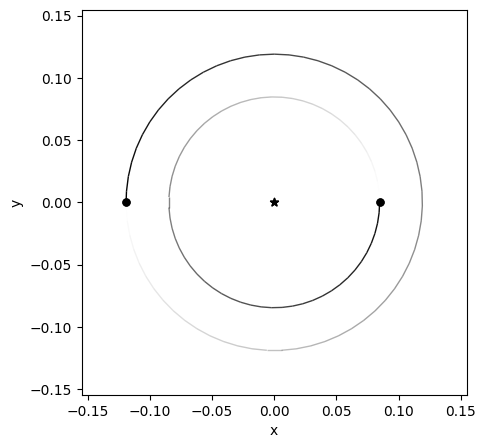

In [ ]:
mySim = setupSimulation()
plotSimulation(mySim)

In [ ]:
sa = runSimulation(mySim)

Number of snapshots: 20001
Time of first and last snapshot: 0.0, 9000.0


In [ ]:
def plotSimulationArchive(sa):
  color = ['','k','r']

  fig = plt.figure(figsize=(5,5),dpi=150)
  ax = fig.add_subplot(111)

  for s in range(0,len(sa)):
      sim = sa[s] #iterate through each snapshot in sa
      ps = sim.particles #intermediate object to simpify the referencing
      for i in range(1,len(ps)): #iterate through each of the particles, skipping the host star
          ax.plot(ps[i].x,ps[i].y,'.',ms=4,color=color[i])

  ax.set_xlabel("x (AU)",fontsize=16)
  ax.set_ylabel("y (AU)",fontsize=16);

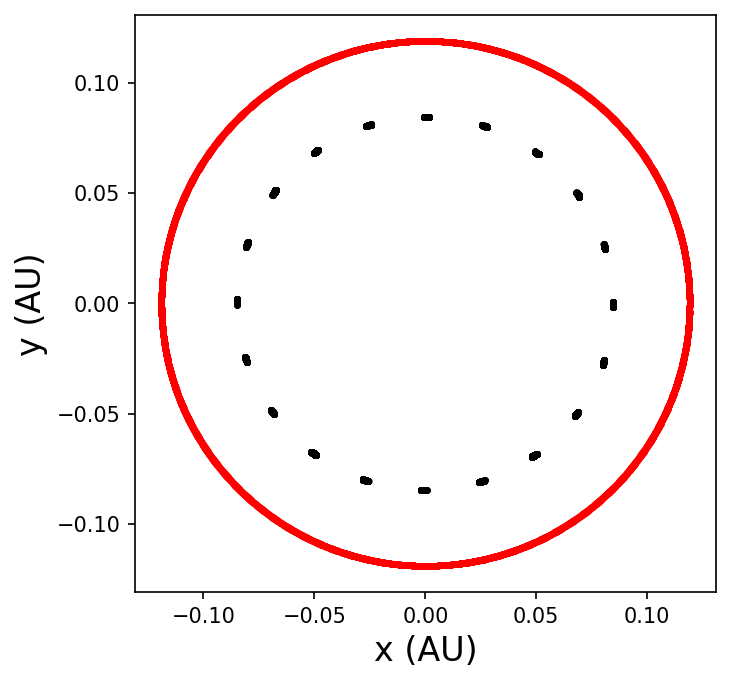

In [ ]:
plotSimulationArchive(sa)

## Simulating $\alpha$ Centauri AB
---

In [ ]:
M_A = 1.133 #mass of star A in solar masses
M_B = 0.972 #mass of star B in solar masses
a_bin = 23.78 #semimajor axis in AU
e_bin = 0.524 #eccentricity
omg_bin = np.radians(77.05) #pericenter of binary converted to radians
MA_bin = np.radians(209.6901) #mean anomaly of binary @ JD 2452276
T_bin = np.sqrt(a_bin**3/(M_A+M_B)) #period of the binary in years (~79.9 years)

In [ ]:
sim = rebound.Simulation()
sim.integrator = 'whfast'
sim.units = ('yr','Msun','AU')
sim.dt = 0.01

sim.add(m=M_A)
sim.add(m=M_B,a=a_bin,e=e_bin,omega=omg_bin,M=MA_bin) #i=Omega=0 by default
sim.move_to_com()  #convert to center of mass coordinates

sim.save_to_file("alphaCen.bin",interval=0.1,delete_file=True)
sim.integrate(T_bin)

In [ ]:
#run the simulation
sa = rebound.Simulationarchive("alphaCen.bin")
print("Number of snapshots: %d" % len(sa))
print("Time of first and last snapshot: %.1f, %.1f" % (sa.tmin, sa.tmax))

Number of snapshots: 800
Time of first and last snapshot: 0.0, 79.9


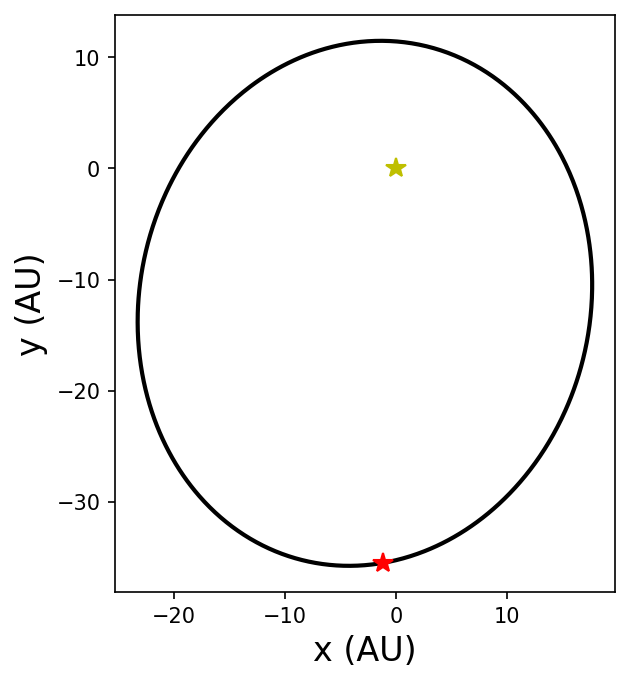

In [ ]:
#plot the simulation
fig = plt.figure(figsize=(5,5),dpi=150)
ax = fig.add_subplot(111)
ax.set_aspect('equal')

ax.plot(0,0,'y*',ms=10)
xy_bin = np.zeros((len(sa),2))
for s in range(0,len(sa)):
    sim = sa[s] #iterate through each snapshot in sa
    ps = sim.particles #intermediate object to simpify the referencing
    sim.move_to_hel() #shift to astrocentric coordinates
    xy_bin[s,:] = [ps[1].x,ps[1].y]
ax.plot(xy_bin[:,0],xy_bin[:,1],'k-',lw=2)
ax.plot(xy_bin[0,0],xy_bin[0,1],'r*',ms=10)
ax.set_xlabel("x (AU)",fontsize=16)
ax.set_ylabel("y (AU)",fontsize=16);

## Adding a Planet
---

In [ ]:
M_A = 1.133 #mass of star A in solar masses
M_B = 0.972 #mass of star B in solar masses
a_bin = 23.78 #semimajor axis in AU
e_bin = 0.524 #eccentricity
omg_bin = np.radians(77.05) #pericenter of binary converted to radians
MA_bin = np.radians(209.6901) #mean anomaly of binary @ JD 2452276
T_bin = np.sqrt(a_bin**3/(M_A+M_B)) #period of the binary in years (~79.9 years)

M_pl = 3.0035e-6 #mass of Earth in solar masses
a_pl = 1. #semimajor axis in AU

In [ ]:
sim = rebound.Simulation()
sim.integrator = 'whfast'
sim.units = ('yr','Msun','AU')
sim.dt = 0.01

sim.add(m=M_A)
sim.add(m=M_pl,a=a_pl)
sim.add(m=M_B,a=a_bin,e=e_bin,omega=omg_bin,M=MA_bin) #i=Omega=0 by default
sim.move_to_com()  #convert to center of mass coordinates

sim.save_to_file("alphaCen_wPl.bin",interval=0.1,delete_file=True)
sim.integrate(T_bin)

In [ ]:
#run the simulation
sa = rebound.Simulationarchive("alphaCen_wPl.bin")
print("Number of snapshots: %d" % len(sa))
print("Time of first and last snapshot: %.1f, %.1f" % (sa.tmin, sa.tmax))

Number of snapshots: 800
Time of first and last snapshot: 0.0, 79.9


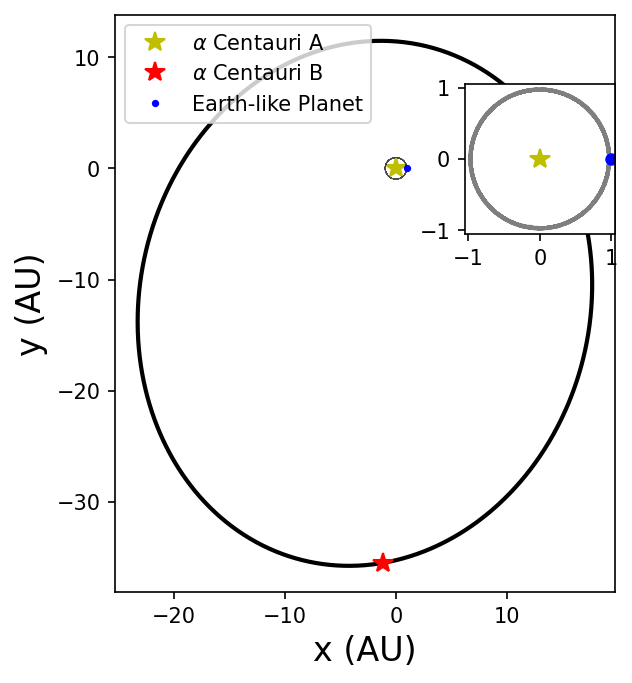

In [ ]:
#plot the simulation
fig = plt.figure(figsize=(5,5),dpi=150)
ax = fig.add_subplot(111)
axins = ax.inset_axes([0.7, 0.5, 0.3, 0.5])
ax.set_aspect('equal')
axins.set_aspect('equal')

ax.plot(0,0,'y*',ms=10, label=r'$\alpha$ Centauri A')
axins.plot(0,0,'y*',ms=10)
xy_bin = np.zeros((len(sa),2))
xy_pl = np.zeros((len(sa),2))
for s in range(0,len(sa)):
    sim = sa[s] #iterate through each snapshot in sa
    ps = sim.particles #intermediate object to simplify the referencing
    sim.move_to_hel() #shift to astrocentric coordinates
    xy_bin[s,:] = [ps[2].x,ps[2].y]
    xy_pl[s,:] = [ps[1].x,ps[1].y]
ax.plot(xy_bin[:,0],xy_bin[:,1],'k-',lw=2)
ax.plot(xy_bin[0,0],xy_bin[0,1],'r*',ms=10, label=r'$\alpha$ Centauri B')
ax.plot(xy_pl[:,0],xy_pl[:,1],'k-',lw=0.1,alpha=0.7)
ax.plot(xy_pl[0,0],xy_pl[0,1],'b.',ms=5, label='Earth-like Planet')

# inset axes to zoom in on planet
fig.canvas.draw()
axins.plot(xy_pl[:,0],xy_pl[:,1],'k-',lw=0.1,alpha=0.5)
axins.plot(xy_pl[0,0],xy_pl[0,1],'b.',ms=10)
axins.set_xlim(-1.05,1.05)
axins.set_ylim(-1.05,1.05)

ax.set_xlabel("x (AU)",fontsize=16)
ax.set_ylabel("y (AU)",fontsize=16)
plt.legend(loc='upper left')
plt.show();

## Animating a Simulation
---

In [ ]:
home = os.getcwd() + "/Tutorials/"
print(home)

/content/Tutorials/


In [ ]:
M_A = 1.133 #mass of star A in solar masses
M_B = 0.972 #mass of star B in solar masses
a_bin = 23.78 #semimajor axis in AU
e_bin = 0.524 #eccentricity
omg_bin = np.radians(77.05) #pericenter of binary converted to radians
MA_bin = np.radians(209.6901) #mean anomaly of binary @ JD 2452276
T_bin = np.sqrt(a_bin**3/(M_A+M_B)) #period of the binary in years

M_pl = 3.0035e-6 #mass of Earth in solar masses
a_pl = 4. #semimajor axis in AU

In [ ]:
sim = rebound.Simulation()
sim.integrator = 'ias15'
sim.units = ('yr','Msun','AU')
sim.dt = 0.001

sim.add(m=M_A)
sim.add(m=M_pl,a=a_pl,primary=sim.particles[0])
sim.add(m=M_B,a=a_bin,e=e_bin,omega=omg_bin,M=MA_bin) #i=Omega=0 by default
sim.move_to_com()  #convert to center of mass coordinates

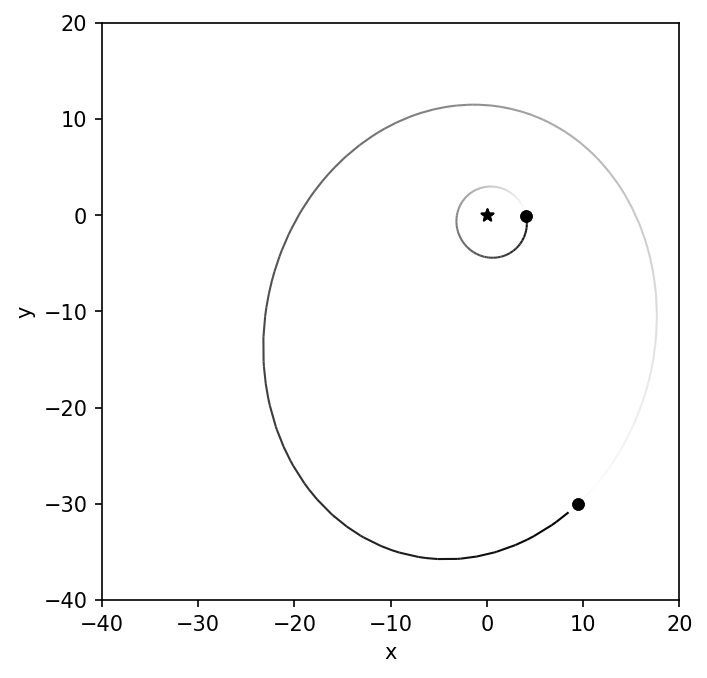

In [ ]:
#Rebound plotting
op = rebound.OrbitPlot(sim)

fig = op.fig
op.update()
op.ax.set_xlim(-40,20)
op.ax.set_ylim(-40,20)
op.fig.set_size_inches(5, 5)
op.fig.set_dpi(150)

if not os.path.exists(home+"Plots/"):
    os.makedirs(home+"Plots/")
else:
    pnglist = [f for f in os.listdir(home+"Plots/") if f.endswith('png')]
    for png in pnglist:
        os.remove(home+"Plots/" + png)

for i in range(0,250):
    op.sim.integrate(sim.t+1)
    sim.move_to_hel()
    op.update()       # update data
    fig.canvas.draw() # redraw figure
    op.fig.savefig(home+"Plots/out_%03d.png" % i, bbox_inches='tight',dpi=150)
    sim.move_to_com()

In [ ]:
!apt install imagemagick

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript gsfonts
  imagemagick-6-common imagemagick-6.q16 libdjvulibre-text libdjvulibre21
  libfftw3-double3 libgs9 libgs9-common libidn12 libijs-0.35 libilmbase25
  libjbig2dec0 libjxr-tools libjxr0 liblqr-1-0 libmagickcore-6.q16-6
  libmagickcore-6.q16-6-extra libmagickwand-6.q16-6 libnetpbm10 libopenexr25
  libwmflite-0.2-7 netpbm poppler-data
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x imagemagick-doc autotrace cups-bsd | lpr | lprng enscript gimp
  gnuplot grads hp2xx html2ps libwmf-bin mplayer povray radiance sane-utils
  texlive-base-bin transfig ufraw-batch libfftw3-bin libfftw3-dev inkscape
  poppler-utils fonts-japanese-mincho | fonts-ipafont-mincho
  fonts-japanese-gothic | fonts-ipafont-gothic fonts-arphic-uka

In [ ]:
%cd /content/Tutorials/Plots/
!convert -delay 10 -loop 0 -dispose previous *.png /content/animation_example.gif

/content/Tutorials/Plots
